# Exercise 2: Statistical Visualization

This exercise focuses on data visualization using `matplotlib` and `seaborn`. It covers the **M3-2: Statistical Visualization** learning outcomes. We will primarily use the Palmer Penguins dataset. Work through the sections in order.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## A. Fundamentals of plotting

**1.** Explain the difference between a `figure` and an `axes` in `matplotlib`. (1-2 sentences)



*(Your answer)*


In [ ]:
In Matplotlib, the Figure is the overall window or page that acts as a container for everything you see, while the Axes is the specific area (the "subplot") where the data is actually plotted, including the lines, markers, and coordinate ticks. Think of the Figure as the canvas and the Axes as a specific drawing framed within that canvas.


**2.** Name the three figure-level functions in `seaborn`.


relplot() (Relational): Used for visualizing relationships between variables, typically via scatter or line plots.

displot() (Distributional): Used for visualizing the distribution of datasets, such as histograms or KDE plots.

catplot() (Categorical): Used for visualizing relationships involving categorical data, like box plots, violin plots, or bar charts.


*(Your answer)*



**3.** Briefly explain the difference between a **Histogram** and a **Barplot**. Which one is used to show the distribution of numerical data, and which is used for categorical data?


A Histogram is used to show the distribution of numerical data by grouping values into continuous intervals called "bins," where the bars touch to represent the continuity of the data. In contrast, a Barplot is used for categorical data to compare specific quantities across distinct categories, with spaces between the bars to emphasize that the groups are separate.

Histogram: Used for numerical data (e.g., age ranges, exam scores).

Barplot: Used for categorical data (e.g., types of fruit, country names).


*(Your answer)*



## B. Subplots and Grids

**1.** Using a seaborn **figure-level** function (like `sns.relplot` or `sns.displot`), create subplots using the `col` and `row` parameters. For example, plot `flipper_length_mm` vs `body_mass_g` across columns for `sex` and rows for `island`.

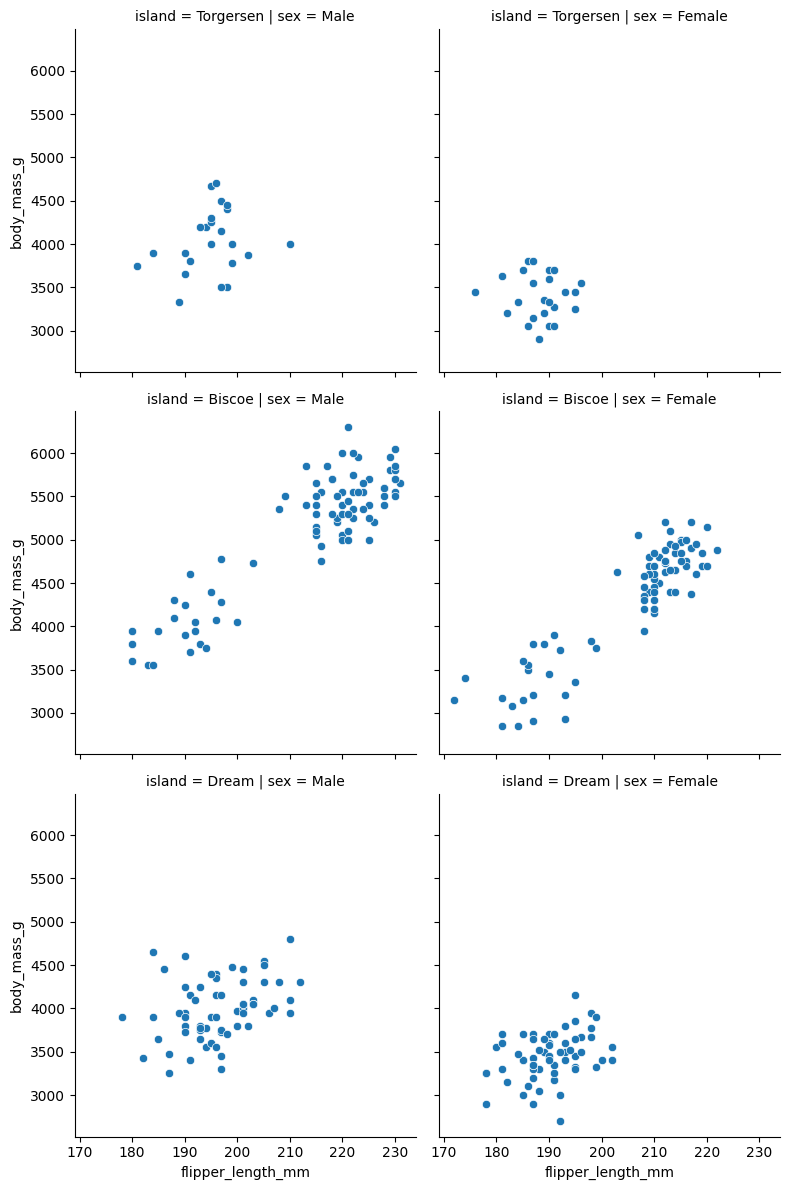

In [2]:
sns.relplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    row="island",
    col="sex",
    kind="scatter",
    height=4,
    aspect=1
)

**2.** Using **axes-level** functions, create a figure with subplots (e.g., 1 row and 2 columns) using `plt.subplots`. 
- Plot a scatterplot of `bill_length_mm` vs `bill_depth_mm` on the first axes (`ax1`).
- Plot a boxplot (or another axes-level plot of your choice) of `bill_length_mm` by `species` on the second axes (`ax2`).
- Make sure to use `sharey=True` (or `sharex=True`) where appropriate so the subplots are linked on the shared dimension.

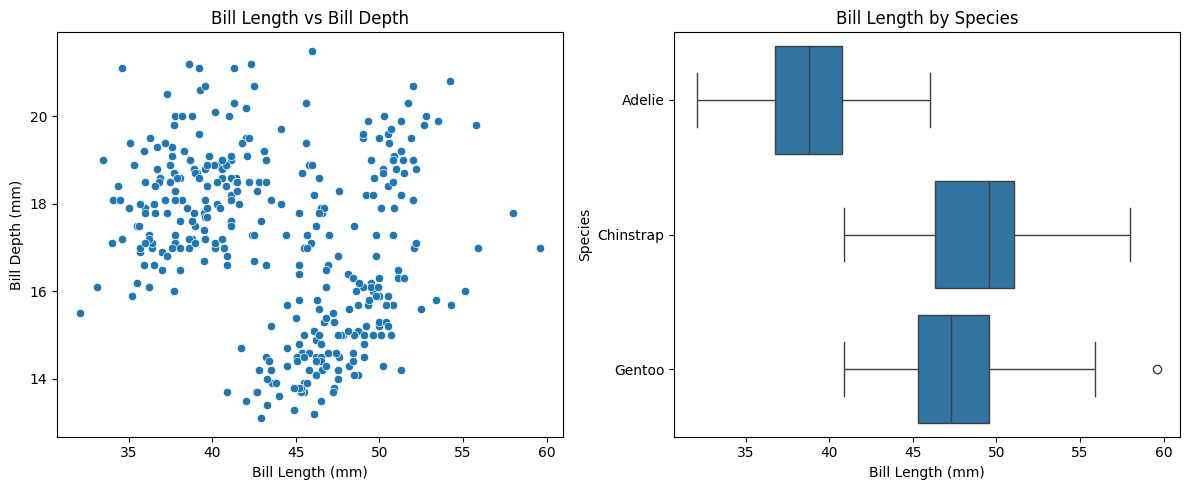

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    ax=ax1
)
ax1.set_title("Bill Length vs Bill Depth")
ax1.set_xlabel("Bill Length (mm)")
ax1.set_ylabel("Bill Depth (mm)")

sns.boxplot(
    data=df,
    x="bill_length_mm",
    y="species",
    ax=ax2
)
ax2.set_title("Bill Length by Species")
ax2.set_xlabel("Bill Length (mm)")
ax2.set_ylabel("Species")

fig.tight_layout()

## C. Visualizing Distributions

**1.** Write code to show a **box plot** of `flipper_length_mm` separated by `species`.

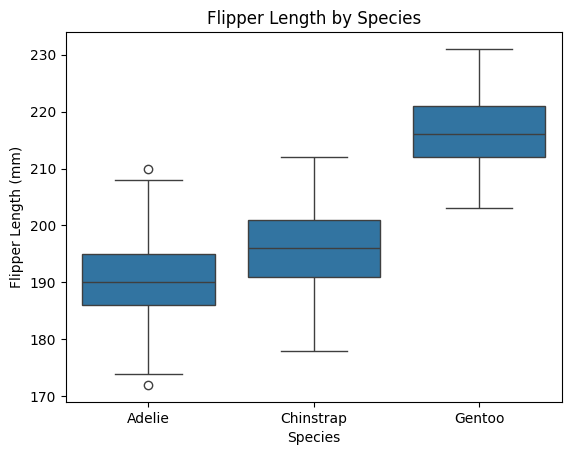

In [4]:
sns.boxplot(data=df, x="species", y="flipper_length_mm")
plt.title("Flipper Length by Species")
plt.xlabel("Species")
plt.ylabel("Flipper Length (mm)")
plt.show()



**2.** Show two distributions on the same figure axes: plot the distribution of `body_mass_g` grouped by `sex` (e.g., using `sns.kdeplot`, or `sns.histplot` with overlapping transparent bins).



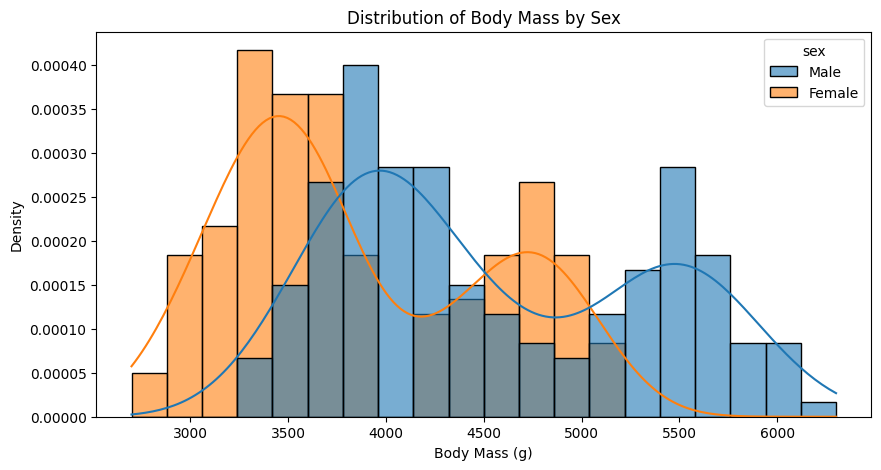

In [5]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="body_mass_g",
    hue="sex",
    kde=True,
    stat="density",
    alpha=0.6,
    bins=20
)

plt.title("Distribution of Body Mass by Sex")
plt.xlabel("Body Mass (g)")
plt.ylabel("Density")
plt.show()



**3.** Plot the Empirical Cumulative Distribution Function (**ECDF**) for `body_mass_g`, split by `species`. Briefly interpret what the plot tells you about how the species compare in weight.



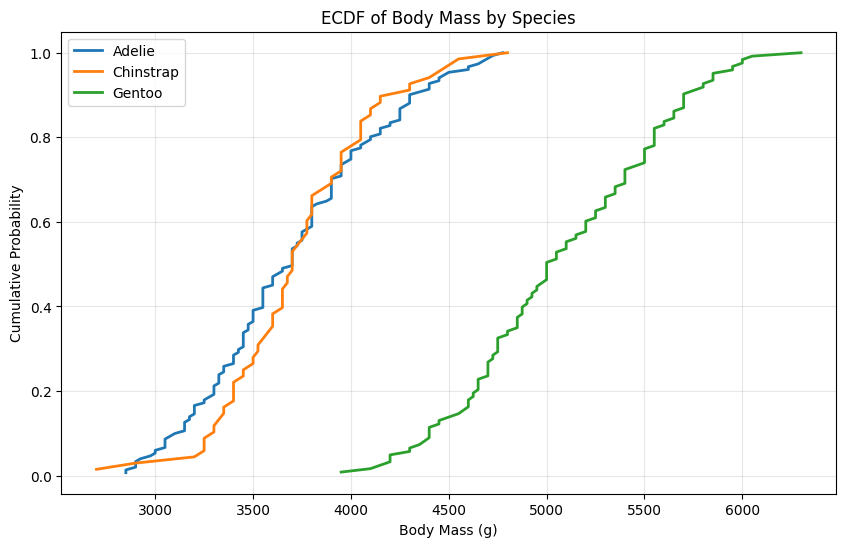

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for species in df['species'].unique():
    species_data = df[df['species'] == species]['body_mass_g'].dropna()
    sorted_data = np.sort(species_data)
    ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, ecdf, label=species, linewidth=2)

ax.set_xlabel('Body Mass (g)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('ECDF of Body Mass by Species')
ax.legend()
ax.grid(alpha=0.3)
plt.show()



*(Your interpretation here)*



**4.** Plot a **bi-variate histogram** using `sns.histplot` showing `bill_length_mm` on the x-axis and `bill_depth_mm` on the y-axis. What does the intensity mapping (the color blocks) represent?



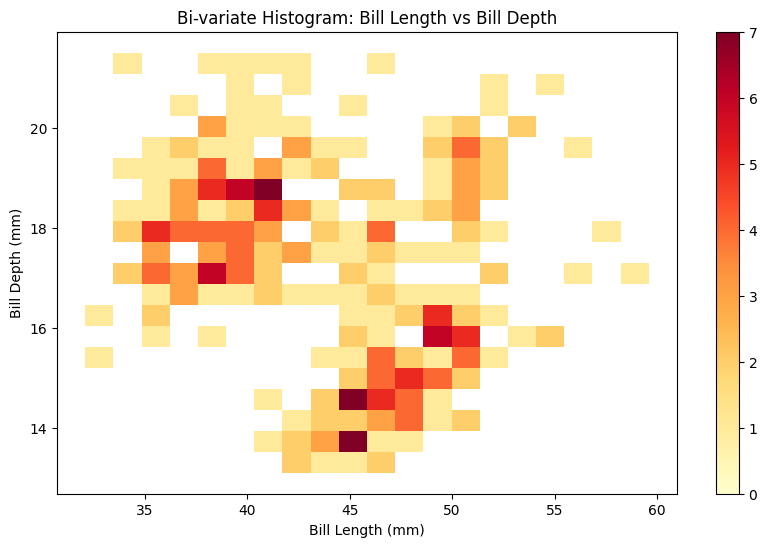

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    cbar=True,
    cmap="YlOrRd",
    bins=20
)

plt.title("Bi-variate Histogram: Bill Length vs Bill Depth")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.show()



*(Your interpretation here)*



## D. Categorical Data

**1.** Visualize numerical vs categorical relationships using `sns.catplot()`. Plot `bill_depth_mm` across different `island`s. Experiment with different categorical plot kinds (e.g., `kind='violin'` or `kind='swarm'`).

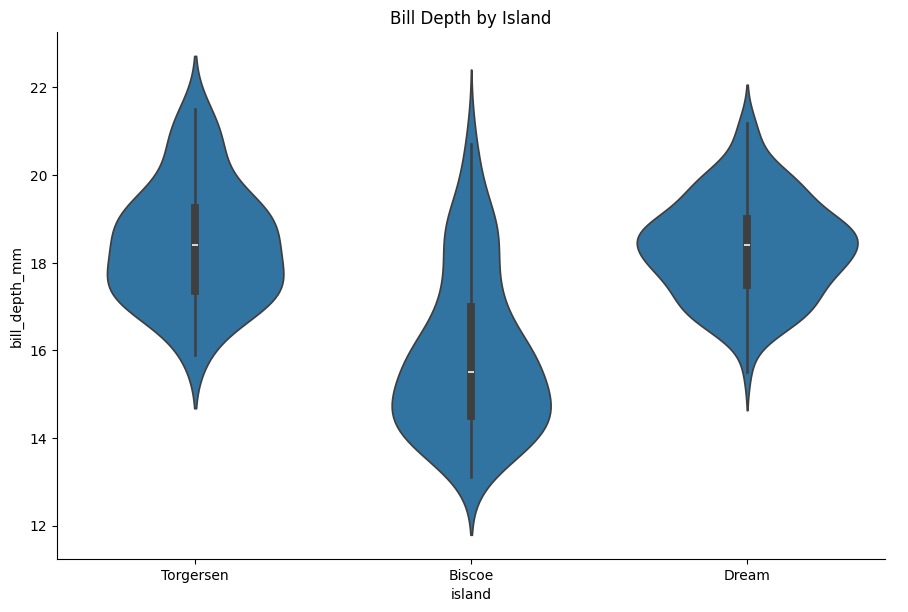

In [8]:
sns.catplot(
    data=df,
    x="island",
    y="bill_depth_mm",
    kind="violin",
    height=6,
    aspect=1.5
)
plt.title("Bill Depth by Island")
plt.show()

**2.** Visualize multiple categorical variables in one plot. Show a count of penguins by `island`, and further separate the counts by `species` (using the `hue` parameter in a count plot or a similar approach).

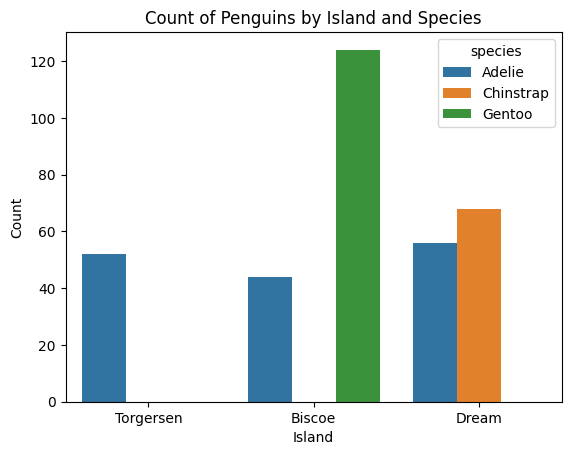

In [9]:
sns.countplot(
    data=df,
    x="island",
    hue="species"
)
plt.title("Count of Penguins by Island and Species")
plt.xlabel("Island")
plt.ylabel("Count")
plt.show()

## E. Relational Plots and Aesthetics

**1.** Relate two numerical variables using a simple **scatter plot**: plot `bill_length_mm` vs `flipper_length_mm`.

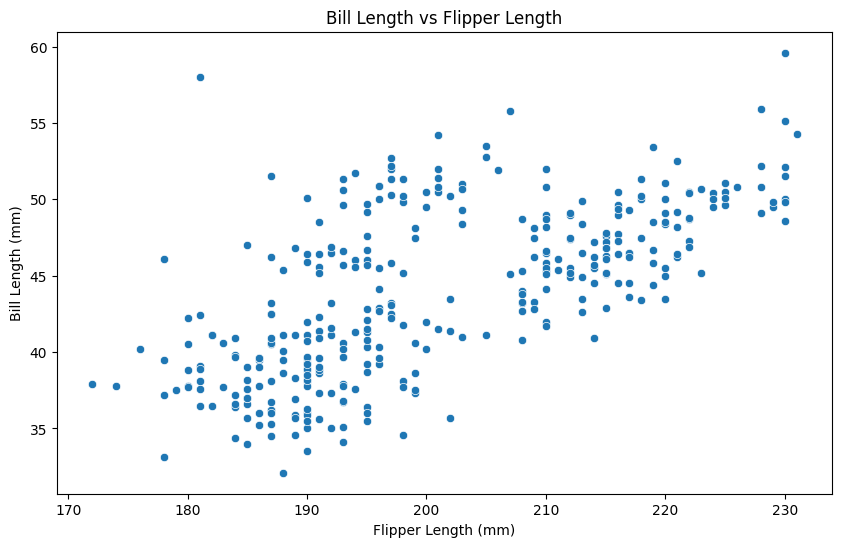

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="bill_length_mm"
)

plt.title("Bill Length vs Flipper Length")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Bill Length (mm)")
plt.show()

**2.** Enhance the scatter plot from the previous step by using different **colors** (`hue`), **markers** (`style`), and **sizes** (`size`) based on other variables in the dataset. Make the plot visually distinct and ensure it is readable.

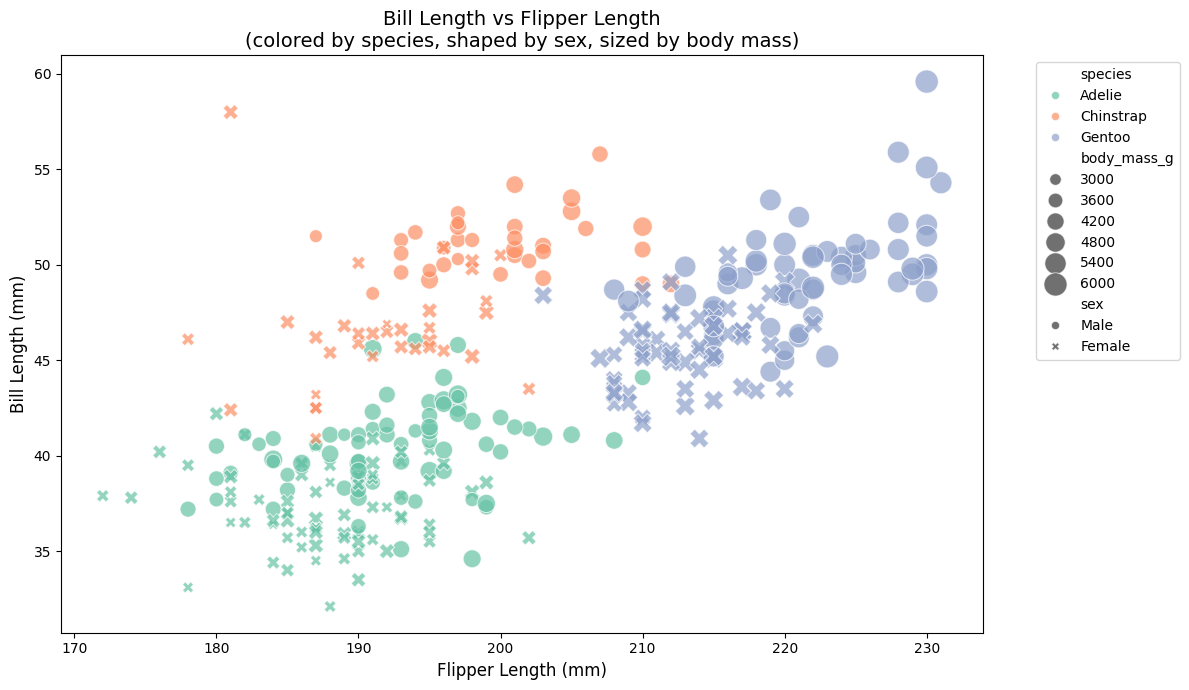

In [11]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="bill_length_mm",
    hue="species",
    style="sex",
    size="body_mass_g",
    palette="Set2",
    sizes=(50, 300),
    alpha=0.7
)

plt.title("Bill Length vs Flipper Length\n(colored by species, shaped by sex, sized by body mass)", fontsize=14)
plt.xlabel("Flipper Length (mm)", fontsize=12)
plt.ylabel("Bill Length (mm)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()